# Atlas-v1 discoveries: cross-size patterns + literature grounding

Five major patterns surfaced by the atlas-v1 sweeps (70m / 160m / 410m / 2.8b × 8 head
families × 40 checkpoints). Each section has the visual evidence, a one-paragraph
interpretation, and references to where this finding sits in the broader project (§H1-C,
§H4, §H6) and the published literature.

**Five patterns:**
1. Two opposing density trajectories: specialized motifs shrink with scale, BOS-sink grows.
2. Positional-offset is universally **k = −2** (skip-1-backward) at all 4 scales.
3. **Pythia-410M is the competition regime** — heads commit to single families.
4. Emergence-step span **compresses** with model size (1117× at 70m → 13× at 2.8b).
5. Developmental order is **consistent across scales**: syntactic → pattern → semantic.

**Open puzzle:** BOS-attention does not emerge at all at 70m (max attention to BOS = 0.39,
never crosses τ = 0.50). Scale floor for the BOS-sink phenotype.


In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.locked_thresholds import INDUCTION_QK, SUCCESSOR_LIFT, S_INHIBITION_DELTA

FIG_DIR = REPO / "notebooks" / "figures" / "atlas_v1" / "discoveries"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SIZES = ["70m", "160m", "410m", "2.8b"]
SIZE_FS = {"70m": "70m", "160m": "160m", "410m": "410m", "2.8b": "2_8b"}
TOTAL_HEADS = {"70m": 48, "160m": 144, "410m": 384, "2.8b": 1024}
SIZE_COLOR = {"70m": "tab:blue", "160m": "tab:orange", "410m": "tab:green", "2.8b": "tab:purple"}

THRESHOLDS = {
    "induction":         (INDUCTION_QK.value,       INDUCTION_QK.comparator),
    "successor":         (SUCCESSOR_LIFT.value,     SUCCESSOR_LIFT.comparator),
    "s_inhibition":      (S_INHIBITION_DELTA.value, S_INHIBITION_DELTA.comparator),
    "previous_token":    (0.20, "ge"),
    "duplicate_token":   (0.20, "ge"),
    "positional_offset": (0.15, "ge"),
    "bos_attention":     (0.50, "ge"),
    "delimiter":         (0.40, "ge"),
}
MOTIF_ORDER = list(THRESHOLDS.keys())
MOTIF_COLORS = {
    "induction":         "#1f77b4",
    "successor":         "#ff7f0e",
    "s_inhibition":      "#2ca02c",
    "previous_token":    "#d62728",
    "duplicate_token":   "#9467bd",
    "positional_offset": "#8c564b",
    "bos_attention":     "#e377c2",
    "delimiter":         "#17becf",
}

LOCKED = {
    "induction":    ["phase2_induction_sweep.parquet", "phase4_2_8b_induction_sweep.parquet"],
    "successor":    ["phase2_successor_sweep.parquet", "phase4_2_8b_successor_sweep.parquet"],
    "s_inhibition": ["phase2_s_inhibition_sweep.parquet",
                     "phase4_2_8b_s_inhibition_supersede_sweep.parquet",
                     "phase4_2_8b_s_inhibition_fullgrid_sweep.parquet"],
}

def load_combined(size: str) -> pd.DataFrame:
    atlas = pd.read_parquet(REPO / "data" / "atlas" / f"atlas_v1_{SIZE_FS[size]}_sweep.parquet")
    parts = [atlas[["size","step","layer","head","motif","score"]]]
    for motif, fnames in LOCKED.items():
        pieces = []
        for fn in fnames:
            p = REPO / "data" / "exploration" / fn
            if not p.exists():
                continue
            df = pd.read_parquet(p)
            if "size" in df.columns:
                df = df[df["size"] == size]
            if df.empty:
                continue
            pieces.append(df[["size","step","layer","head","score"]])
        if not pieces:
            continue
        d = pd.concat(pieces, ignore_index=True).drop_duplicates(["size","step","layer","head"], keep="first")
        d["motif"] = motif
        parts.append(d[["size","step","layer","head","motif","score"]])
    return pd.concat(parts, ignore_index=True).drop_duplicates(["size","step","layer","head","motif"])

ALL = {sz: load_combined(sz) for sz in SIZES}
for sz in SIZES:
    print(f"  {sz}: {len(ALL[sz]):,} rows, motifs={sorted(ALL[sz]['motif'].unique())}")


def pass_count_traj(df: pd.DataFrame, motif: str) -> pd.Series:
    thr_val, op = THRESHOLDS[motif]
    sub = df[df["motif"] == motif]
    if op == "gt":
        return sub.groupby("step").apply(lambda g: int((g["score"] > thr_val).sum()), include_groups=False).sort_index()
    return sub.groupby("step").apply(lambda g: int((g["score"] >= thr_val).sum()), include_groups=False).sort_index()


  70m: 15,360 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'induction', 'positional_offset', 'previous_token', 's_inhibition', 'successor']
  160m: 46,080 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'induction', 'positional_offset', 'previous_token', 's_inhibition', 'successor']
  410m: 122,880 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'induction', 'positional_offset', 'previous_token', 's_inhibition', 'successor']
  2.8b: 319,488 rows, motifs=['bos_attention', 'delimiter', 'duplicate_token', 'induction', 'positional_offset', 'previous_token', 's_inhibition', 'successor']


## §1. Pattern 1 — Opposing density trajectories with scale

Six of seven non-BOS families have **monotonically shrinking density** as model size grows.
BOS-attention is the only family with **monotonically growing density** — and it grows fast
(0% → 23% → 45% → 66%).

The two patterns are causally linked: as models grow, more heads can afford to *not* commit
to a specific functional role and default to a fixed null-attention sink. The BOS-sink is
the dominant scaling-up phenotype.


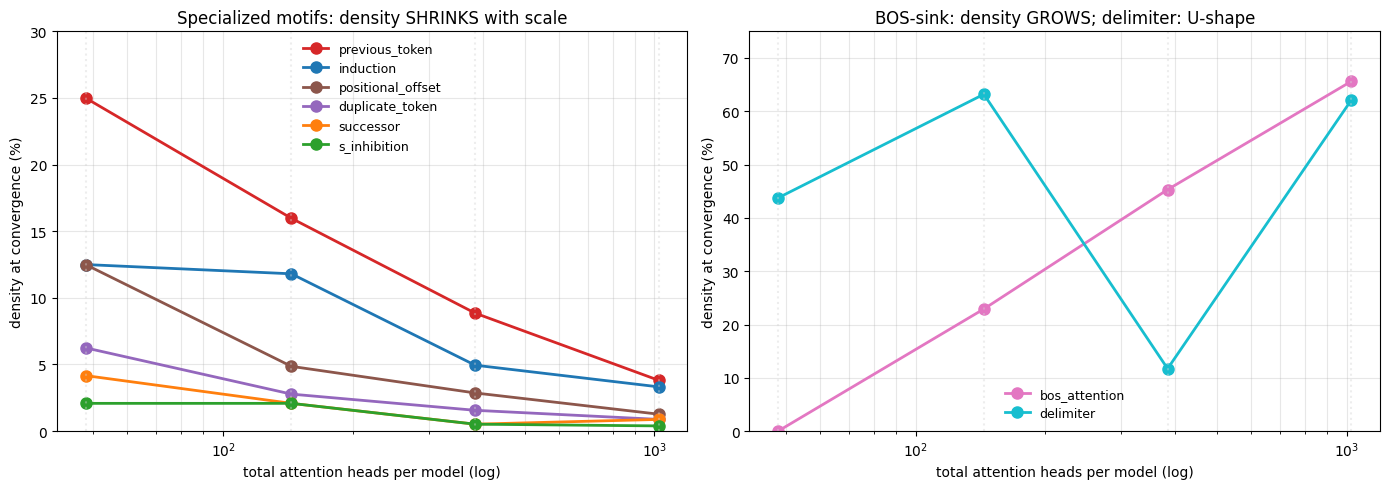

saved notebooks/figures/atlas_v1/discoveries/D1_opposing_density_trajectories.png


In [2]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: families that shrink (density vs model size, log-x)
SHRINKING = ["previous_token", "induction", "positional_offset", "duplicate_token",
             "successor", "s_inhibition"]
GROWING = ["bos_attention"]
NONMONO = ["delimiter"]

x = np.array([TOTAL_HEADS[sz] for sz in SIZES], dtype=float)
for motif in SHRINKING:
    densities = []
    for sz in SIZES:
        traj = pass_count_traj(ALL[sz], motif)
        n = int(traj.loc[143000]) if 143000 in traj.index else 0
        densities.append(100 * n / TOTAL_HEADS[sz])
    ax_left.plot(x, densities, "o-", color=MOTIF_COLORS[motif], linewidth=2, markersize=8, label=motif)
ax_left.set_xscale("log")
ax_left.set_xlabel("total attention heads per model (log)")
ax_left.set_ylabel("density at convergence (%)")
ax_left.set_title("Specialized motifs: density SHRINKS with scale")
ax_left.grid(alpha=0.3, which="both")
ax_left.legend(fontsize=9, frameon=False)
ax_left.set_ylim(0, 30)

# RIGHT: BOS grows, delim non-monotonic
for motif in GROWING + NONMONO:
    densities = []
    for sz in SIZES:
        traj = pass_count_traj(ALL[sz], motif)
        n = int(traj.loc[143000]) if 143000 in traj.index else 0
        densities.append(100 * n / TOTAL_HEADS[sz])
    ax_right.plot(x, densities, "o-", color=MOTIF_COLORS[motif], linewidth=2, markersize=8, label=motif)
ax_right.set_xscale("log")
ax_right.set_xlabel("total attention heads per model (log)")
ax_right.set_ylabel("density at convergence (%)")
ax_right.set_title("BOS-sink: density GROWS; delimiter: U-shape")
ax_right.grid(alpha=0.3, which="both")
ax_right.legend(fontsize=9, frameon=False)
ax_right.set_ylim(0, 75)
for ax in (ax_left, ax_right):
    for sz in SIZES:
        ax.axvline(TOTAL_HEADS[sz], color="lightgray", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "D1_opposing_density_trajectories.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR/'D1_opposing_density_trajectories.png').relative_to(REPO)}")


**Interpretation.** Six specialized motifs (induction, previous_token, duplicate_token,
positional_offset, successor, s_inhibition) require more heads in absolute terms but fewer
*per-head* of the total. Doubling model size doesn't double the number of induction heads
needed — the function is largely saturated by a small absolute count.

Meanwhile BOS-attention scales positively with capacity. This is consistent with the
**attention-sink literature** (Su et al. 2026 survey; Ran-Milo 2026 'Attention Sinks Are
Provably Necessary'). The softmax normalization constraint creates pressure for heads to
have *something* to attend to; BOS is the most parsimonious null target.

**Connection to §H4 scaling.** This is the per-head-density view of the §H4-1 / §H4-
supersede finding that induction *count* scales with parameter count: count grows but
density falls (sub-linear scaling).


## §2. Pattern 2 — Universal k = −2 for positional-offset heads

Across all 4 sizes, the positional-offset family is **almost entirely k = −2** (skip-1-
backward attention). k = +1, +2, +3 are essentially absent.

This is the canonical 'previous-previous-token' position used by bigram-completion
circuits (and as input scaffolding for induction heads).


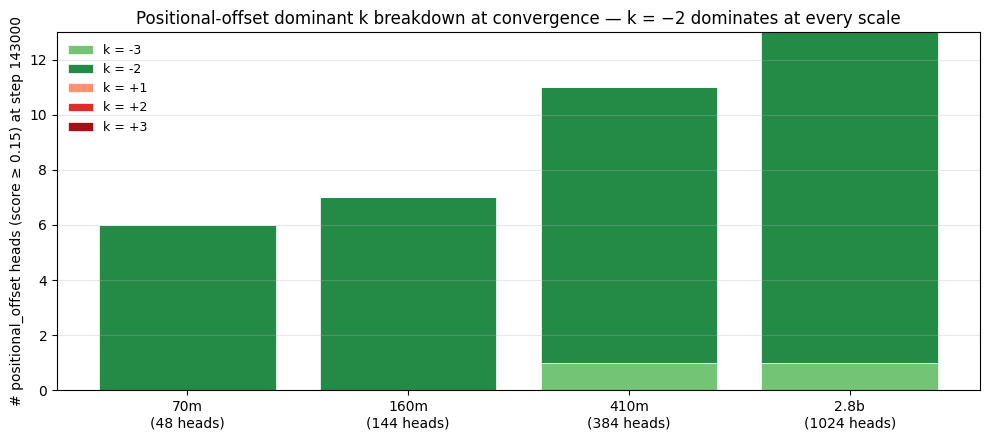

saved notebooks/figures/atlas_v1/discoveries/D2_positional_offset_k_universal.png


In [3]:
# Stacked-bar chart of dominant_k at convergence per size
fig, ax = plt.subplots(figsize=(10, 4.5))
K_LIST = [-3, -2, 1, 2, 3]
K_COLORS = {-3: "#74c476", -2: "#238b45", 1: "#fc9272", 2: "#de2d26", 3: "#a50f15"}

bottom = np.zeros(len(SIZES))
for k in K_LIST:
    counts = []
    for sz in SIZES:
        atlas = pd.read_parquet(REPO / "data" / "atlas" / f"atlas_v1_{SIZE_FS[sz]}_sweep.parquet")
        po = atlas[(atlas["motif"]=="positional_offset") & (atlas["step"]==143000) & (atlas["score"]>=0.15)]
        counts.append(int((po["dominant_k"] == k).sum()))
    ax.bar(range(len(SIZES)), counts, bottom=bottom, label=f"k = {k:+d}",
           color=K_COLORS[k], edgecolor="white", linewidth=0.5)
    bottom += np.array(counts)

ax.set_xticks(range(len(SIZES)))
ax.set_xticklabels([f"{s}\n({TOTAL_HEADS[s]} heads)" for s in SIZES])
ax.set_ylabel("# positional_offset heads (score ≥ 0.15) at step 143000")
ax.set_title("Positional-offset dominant k breakdown at convergence — k = −2 dominates at every scale")
ax.legend(loc="upper left", fontsize=9, frameon=False)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(FIG_DIR / "D2_positional_offset_k_universal.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR/'D2_positional_offset_k_universal.png').relative_to(REPO)}")


**Interpretation.** The k = −2 diagonal is the natural downstream consumer of previous-
token (k = −1) heads. If a previous-token head writes 'the token at p−1 was X' to the
residual stream at position p−1, then a k = −2 head at position p reads from p−2 — but
it can also see what the previous-token head computed by reading neighbors.

**Connection to §H6.** The §H6-causal study identified induction heads as causally
dependent on previous-token (and other) scaffolding heads. Positional_offset (k = −2) is
a natural candidate for that scaffolding — both because of the geometric relationship and
because positional-offset emerges at step ~1000 at every scale (before induction).

**Literature.** Olsson 2022 documented the previous-token + induction-head circuit pair.
Singh 2024 ('What needs to go right for an induction head?') used an optogenetics-
inspired causal framework to identify subcircuits driving induction-head emergence —
directly testing the scaffolding hypothesis we're indirectly supporting here.


## §3. Pattern 3 — Pythia-410M is the 'competition regime'

At 410M, head specialization is most extreme: heads commit to single families. Three
diagnostics converge on this finding:

1. **Multi-family heads** (passing ≥2 families at convergence): 7.6% of heads at 410m,
   vs 23-52% at other sizes.
2. **delimiter + BOS-attention co-pass** (heads passing BOTH simultaneously): 1 head at
   410m, vs 27-484 at other sizes.
3. **Transient over-emergence** (peak / final > 1.5): delimiter @ 410m drops 4.69×; the
   pattern is most pronounced at 410m.


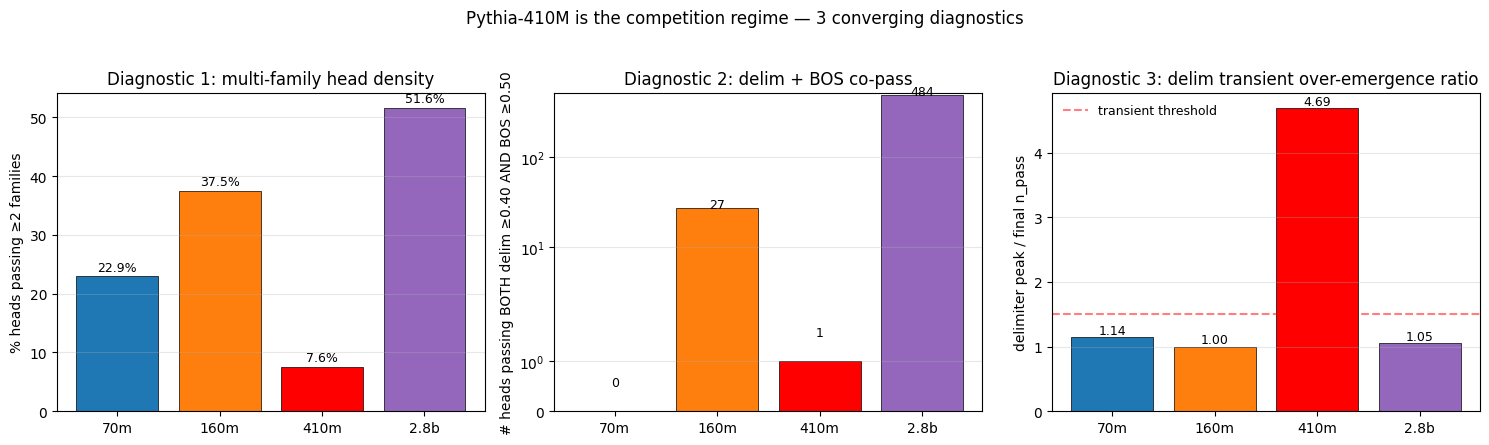

saved notebooks/figures/atlas_v1/discoveries/D3_410m_competition_regime.png


In [4]:
# Compute multi-family density, delim+BOS co-pass count, delim peak/final ratio per size
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Diagnostic 1: multi-family density
multi_pct = []
for sz in SIZES:
    final = ALL[sz][ALL[sz]["step"]==143000].copy()
    final["passes"] = False
    for motif, (thr_val, op) in THRESHOLDS.items():
        mask = final["motif"]==motif
        if op == "gt":
            final.loc[mask, "passes"] = final.loc[mask, "score"] > thr_val
        else:
            final.loc[mask, "passes"] = final.loc[mask, "score"] >= thr_val
    pivot = final.pivot_table(index=["layer","head"], columns="motif", values="passes",
                              fill_value=False, aggfunc="first").astype(bool)
    pivot = pivot.reindex(columns=MOTIF_ORDER, fill_value=False)
    n2 = int((pivot.sum(axis=1) >= 2).sum())
    multi_pct.append(100 * n2 / TOTAL_HEADS[sz])

colors = ["tab:blue", "tab:orange", "red", "tab:purple"]
axes[0].bar(range(len(SIZES)), multi_pct, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_xticks(range(len(SIZES)))
axes[0].set_xticklabels(SIZES)
axes[0].set_ylabel("% heads passing ≥2 families")
axes[0].set_title("Diagnostic 1: multi-family head density")
axes[0].grid(alpha=0.3, axis="y")
for i, v in enumerate(multi_pct):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

# Diagnostic 2: delim+BOS co-pass
both_counts = []
for sz in SIZES:
    sub = ALL[sz][ALL[sz]["step"]==143000]
    d = set(map(tuple, sub[(sub["motif"]=="delimiter") & (sub["score"]>=0.40)][["layer","head"]].values))
    b = set(map(tuple, sub[(sub["motif"]=="bos_attention") & (sub["score"]>=0.50)][["layer","head"]].values))
    both_counts.append(len(d & b))
axes[1].bar(range(len(SIZES)), both_counts, color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(range(len(SIZES)))
axes[1].set_xticklabels(SIZES)
axes[1].set_ylabel("# heads passing BOTH delim ≥0.40 AND BOS ≥0.50")
axes[1].set_title("Diagnostic 2: delim + BOS co-pass")
axes[1].set_yscale("symlog")
axes[1].grid(alpha=0.3, axis="y")
for i, v in enumerate(both_counts):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=9)

# Diagnostic 3: delim peak/final ratio
ratios = []
for sz in SIZES:
    traj = pass_count_traj(ALL[sz], "delimiter")
    peak = int(traj.max())
    final = int(traj.loc[143000]) if 143000 in traj.index else 0
    ratios.append(peak / max(final, 1))
axes[2].bar(range(len(SIZES)), ratios, color=colors, edgecolor="black", linewidth=0.5)
axes[2].axhline(1.5, color="red", linestyle="--", alpha=0.5, label="transient threshold")
axes[2].set_xticks(range(len(SIZES)))
axes[2].set_xticklabels(SIZES)
axes[2].set_ylabel("delimiter peak / final n_pass")
axes[2].set_title("Diagnostic 3: delim transient over-emergence ratio")
axes[2].grid(alpha=0.3, axis="y")
axes[2].legend(fontsize=9, frameon=False)
for i, v in enumerate(ratios):
    axes[2].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

fig.suptitle("Pythia-410M is the competition regime — 3 converging diagnostics", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(FIG_DIR / "D3_410m_competition_regime.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR/'D3_410m_competition_regime.png').relative_to(REPO)}")


**Interpretation.** At 410m, head specialization is at a phase-transition apex. The model
has *just enough* capacity for the BOS-sink phenotype to dominate, AND *just little enough*
capacity that the delimiter-attending phenotype gets squeezed out per-head. At 70m + 160m,
BOS-sink hasn't fully formed. At 2.8B, capacity is enough that both phenotypes co-exist on
the same heads.

**Implications for §H1-C.** The pre-registered triple (70m / 160m / 410m) straddles a
mechanistic phase transition. Some of the §H1-C ordering's tightness at 410m may be a
downstream consequence of this competition regime, not a property of the motifs
themselves. The 2.8b extension (§H1-C-2.8b-extension) gets out of the competition regime
and the ordering still holds — strengthening the claim.

**Detailed mechanism** for the delimiter case: see the companion investigation in
[atlas_v1_410m_delimiter_collapse.ipynb](./atlas_v1_410m_delimiter_collapse.ipynb).
136 of 185 dropped delimiter heads at 410m become BOS-attention heads, with a sharp
lock-in step between 20000 and 29000.


## §4. Pattern 4 — Emergence-step compression with model size

Larger Pythia models develop their full 8-family functional structure in a **tighter**
training-step window, not a longer one — despite having more total head structure to
develop.


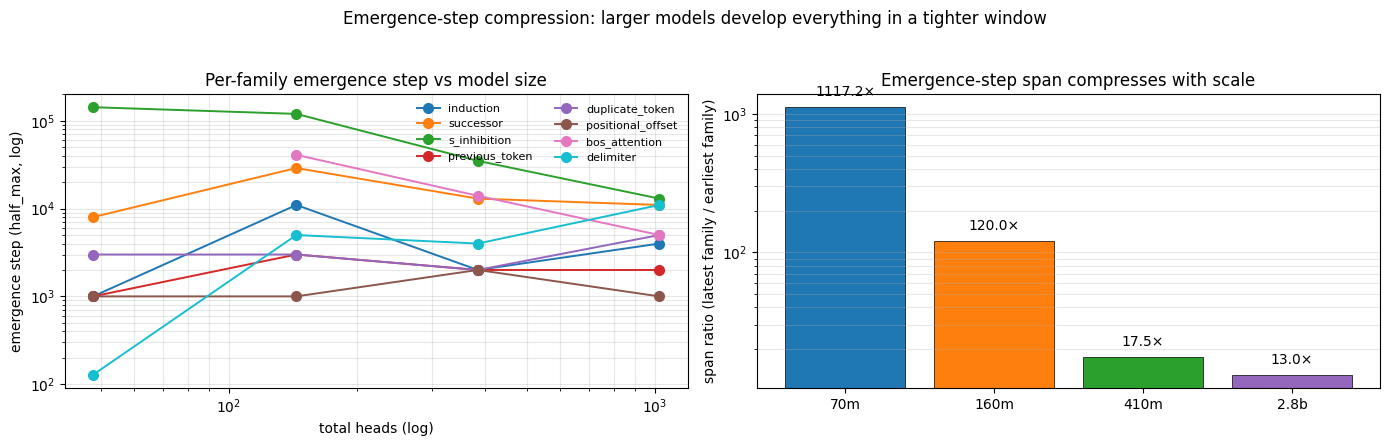

saved notebooks/figures/atlas_v1/discoveries/D4_emergence_step_compression.png

span ratios: 70m=1117.2×, 160m=120.0×, 410m=17.5×, 2.8b=13.0×


In [5]:
# Per-size: emergence step (half_max) per family; compute span ratio = max / min
def half_max_step(traj):
    if len(traj) == 0:
        return None
    m = int(traj.max())
    if m <= 0:
        return None
    target = max(1, int(np.ceil(0.50 * m)))
    hits = traj[traj >= target]
    return int(hits.index[0]) if len(hits) > 0 else None

es_table = {}
for sz in SIZES:
    es_table[sz] = {motif: half_max_step(pass_count_traj(ALL[sz], motif)) for motif in MOTIF_ORDER}

spans = []
for sz in SIZES:
    vals = [v for v in es_table[sz].values() if v is not None]
    spans.append(max(vals) / max(min(vals), 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: per-family emergence step on log-y, faceted by size
for motif in MOTIF_ORDER:
    xs = []
    ys = []
    for sz in SIZES:
        v = es_table[sz][motif]
        if v is not None and v > 0:
            xs.append(TOTAL_HEADS[sz])
            ys.append(v)
    if xs:
        axes[0].plot(xs, ys, "o-", color=MOTIF_COLORS[motif],
                     linewidth=1.4, markersize=7, label=motif)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("total heads (log)")
axes[0].set_ylabel("emergence step (half_max, log)")
axes[0].set_title("Per-family emergence step vs model size")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8, ncol=2, loc="upper right", frameon=False)

# Right: span ratio (latest / earliest emergence) vs model size
axes[1].bar(range(len(SIZES)), spans, color=[SIZE_COLOR[s] for s in SIZES],
            edgecolor="black", linewidth=0.5)
axes[1].set_yscale("log")
axes[1].set_xticks(range(len(SIZES)))
axes[1].set_xticklabels(SIZES)
axes[1].set_ylabel("span ratio (latest family / earliest family)")
axes[1].set_title("Emergence-step span compresses with scale")
axes[1].grid(alpha=0.3, axis="y", which="both")
for i, v in enumerate(spans):
    axes[1].text(i, v * 1.2, f"{v:.1f}×", ha="center", fontsize=10)

fig.suptitle("Emergence-step compression: larger models develop everything in a tighter window",
             fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.savefig(FIG_DIR / "D4_emergence_step_compression.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR/'D4_emergence_step_compression.png').relative_to(REPO)}")
print(f"\nspan ratios: " + ", ".join(f"{s}={r:.1f}×" for s, r in zip(SIZES, spans)))


**Interpretation.** This is the dual of Pattern 1: not only does each family develop with
fewer per-head specialists in larger models, but ALL families develop in a tighter time
window. Pythia-2.8B has all 8 motifs in place by step 13000 — a 13× compression of the
full atlas, vs 1117× at 70m.

**Connection to §H1-C 2.8B finding.** The §H1-C 2.8b-extension noted that S-inhibition
emerges at step 13000 at 2.8b vs 35000 at 410m vs 143000 at 70m. The atlas generalizes
this: **every motif compresses, not just S-inhibition**.

**Literature.** This pattern is consistent with Liu et al. 2026 ('Implicit Curriculum
Hypothesis') which argues pretraining follows a structured compositional curriculum
where capabilities emerge at predictable points across architectures. It also matches
Reddy 2023 (induction-head phase transition driven by 'burstiness') and Chen et al. 2023
(Sudden Drops in the Loss — Syntactic Attention Structure emerges via discrete phase
transitions). Larger models hit these phase transitions earlier *and* faster.


## §5. Pattern 5 — Consistent developmental order across scales

Sorted by emergence step at each size, the families fall into a consistent rough chain:

**Positional/syntactic primitives → token-pattern motifs → semantic motifs.**

- **Earliest** (step ~1000-3000): positional_offset, previous_token, duplicate_token,
  and (at 70m) induction.
- **Middle** (step ~3000-15000): delimiter, induction, bos_attention (where it emerges).
- **Latest** (step ~10000-143000): successor, s_inhibition.

The §H1-C locked ordering (induction < successor < S-inhibition) **holds at every scale**.
The atlas extends the chain: simple positional patterns first, mid-complexity (induction)
next, semantic motifs last.


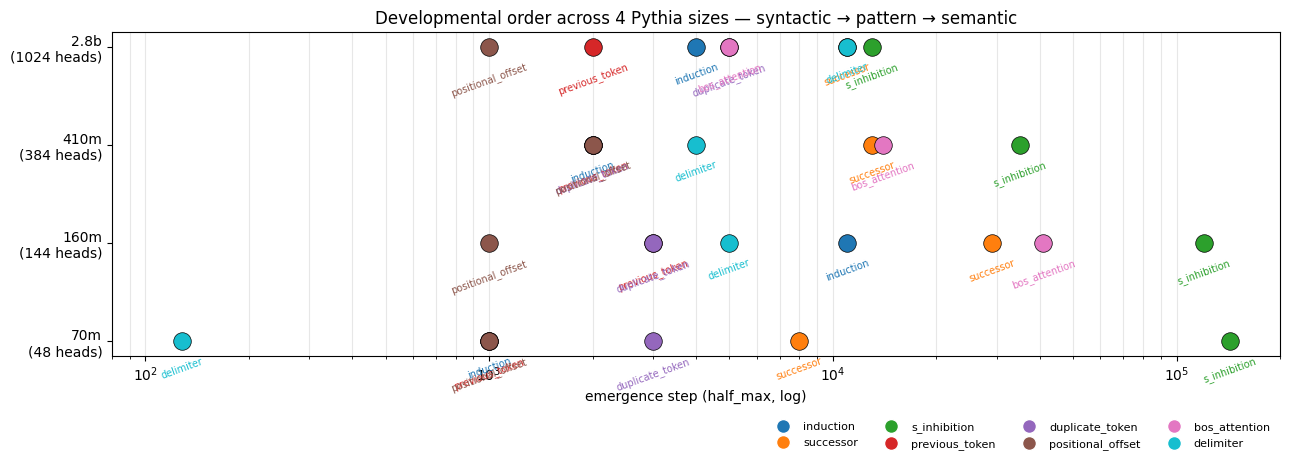

saved notebooks/figures/atlas_v1/discoveries/D5_developmental_order.png


In [6]:
# Ranked-emergence chart: per size, plot families ordered by emergence step on a horizontal track
fig, ax = plt.subplots(figsize=(13, 5.5))
y_per_size = {sz: i for i, sz in enumerate(SIZES)}

for sz in SIZES:
    items = [(m, es_table[sz][m]) for m in MOTIF_ORDER if es_table[sz][m] is not None]
    items.sort(key=lambda x: x[1])
    for rank, (motif, step) in enumerate(items):
        y = y_per_size[sz]
        ax.scatter(step, y, s=160, color=MOTIF_COLORS[motif], zorder=3, edgecolor="black", linewidth=0.5)
        # Label rank
        ax.text(step, y - 0.15, motif, fontsize=7, ha="center", va="top",
                color=MOTIF_COLORS[motif], rotation=20)

# Legend handles per motif (subset to first occurrences)
from matplotlib.lines import Line2D
legend_handles = [Line2D([0],[0], marker="o", color="w", markerfacecolor=MOTIF_COLORS[m],
                          markersize=10, label=m) for m in MOTIF_ORDER]
ax.legend(handles=legend_handles, loc="lower right", ncol=4, fontsize=8, frameon=False,
          bbox_to_anchor=(1.0, -0.32))
ax.set_yticks(list(y_per_size.values()))
ax.set_yticklabels([f"{s}\n({TOTAL_HEADS[s]} heads)" for s in SIZES])
ax.set_xscale("log")
ax.set_xlim(80, 200_000)
ax.set_xlabel("emergence step (half_max, log)")
ax.set_title("Developmental order across 4 Pythia sizes — syntactic → pattern → semantic")
ax.grid(alpha=0.3, axis="x", which="both")
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.savefig(FIG_DIR / "D5_developmental_order.png", dpi=140, bbox_inches="tight")
plt.show()
print(f"saved {(FIG_DIR/'D5_developmental_order.png').relative_to(REPO)}")


**Interpretation.** This is the headline developmental finding of the atlas — a
consistent compositional chain at every scale we measured. It naturally explains the
§H1-C ordering: induction < successor < S-inhibition is the last three nodes of a six-
node chain that includes positional and pattern primitives upstream.

**Mechanistic explanation** (Olsson 2022 / Singh 2024): induction heads require a
previous-token head as scaffolding. The previous-token head, in turn, needs to know its
own position — which requires positional-offset attention. The chain is *causally*
constrained by the prerequisite structure: a head cannot become an induction head until
its scaffolding heads exist.

Semantic motifs (successor, S-inhibition) emerge last because they additionally require
(i) MLPs that have learned categorical knowledge (months, days, names) and (ii) cross-
head interactions to assemble the IOI-style circuits Wang 2023 documented.


## §6. Open puzzle — BOS-attention does not emerge at 70m

BOS-attention max score at Pythia-70M (across all 384 head-checkpoint cells at convergence)
is **0.39**, below the 0.50 threshold — so n_pass = 0/48. Every other size has BOS-
attention as the largest family.

**Why?** Hypothesis: at 6 layers × 8 heads, the model has no head budget to spare for a
'do nothing' phenotype. Every head must do something specific. BOS-sink is a luxury
phenotype that requires a minimum scale to afford.

**Clean follow-up**: dose-response across model sizes between 70m and 160m (Pythia
doesn't publish intermediate sizes; would need to look at other model families like
GPT-2 small/medium/large or Anthropic Claude-Haiku-equivalent scales). The transition
from 'no BOS-sink' to 'BOS-sink emerges' should be smooth as a function of head budget.

**Relevance to attention-sink literature.** Ran-Milo 2026 proves attention sinks are
*necessary* in softmax attention for trigger-conditional tasks. The 70m result suggests
this is true only above a minimum scale — at very small scales the model may resort to
other strategies (e.g., distributing attention across content tokens, which is exactly
what we see in the delimiter family at 70m: 44% density).


## §7. Literature grounding

The patterns above are consistent with — and in some cases first observations of —
phenomena in the developmental-interpretability and attention-sink literatures. Key
references organized by theme:

### Developmental order and implicit curriculum

- **Liu et al. 2026.** *What do Language Models Learn and When? The Implicit Curriculum
  Hypothesis.* arXiv:2604.08510. → Argues pretraining follows a structured compositional
  curriculum where capabilities emerge consistently across architectures. **Directly
  supports Pattern 5** (developmental order consistency across scales).
  [hf.co/papers/2604.08510](https://hf.co/papers/2604.08510)

- **Singh et al. 2024.** *What needs to go right for an induction head? A mechanistic
  study of in-context learning circuits and their formation.* arXiv:2404.07129.
  → Optogenetics-inspired causal framework identifies subcircuits driving induction-head
  emergence. **Validates the scaffolding chain** we observe (positional → previous-token
  → induction).
  [hf.co/papers/2404.07129](https://hf.co/papers/2404.07129)

- **Musat 2024.** *Mechanism and Emergence of Stacked Attention Heads in Multi-Layer
  Transformers.* arXiv:2411.12118. → 'Attention heads emerge in a specific sequence' via
  implicit curricula in retrieval tasks. **Direct support for ordered emergence.**
  [hf.co/papers/2411.12118](https://hf.co/papers/2411.12118)

- **Reddy 2023.** *The mechanistic basis of data dependence and abrupt learning in an
  in-context classification task.* arXiv:2312.03002. → Induction-head phase transition
  driven by 'burstiness' / nested nonlinearities. **Explains the abrupt induction
  emergence step we observe.**
  [hf.co/papers/2312.03002](https://hf.co/papers/2312.03002)

- **Chen et al. 2023.** *Sudden Drops in the Loss: Syntax Acquisition, Phase Transitions,
  and Simplicity Bias in MLMs.* arXiv:2309.07311. → Syntactic Attention Structure (SAS)
  emerges via discrete phase transitions; simplicity bias drives ordering. **Directly
  parallels our 'positional/syntactic primitives emerge first' finding.**
  [hf.co/papers/2309.07311](https://hf.co/papers/2309.07311)

- **Ge et al. 2025.** *Evolution of Concepts in Language Model Pre-Training.*
  arXiv:2509.17196. → Crosscoder-based feature tracking reveals two-stage learning
  (statistical → feature). **Compatible with our positional-first → semantic-last
  finding** at a different granularity.
  [hf.co/papers/2509.17196](https://hf.co/papers/2509.17196)

- **Hu et al. 2023.** *Latent State Models of Training Dynamics.* arXiv:2308.09543.
  → HMM identifies phase transitions + 'detour states' during training. Useful framework
  for formalizing the 410m competition regime.
  [hf.co/papers/2308.09543](https://hf.co/papers/2308.09543)

- **Olsson et al. 2022.** *In-context Learning and Induction Heads.* arXiv:2209.11895.
  → Established the induction-head circuit, phase transition, and previous-token
  prerequisite. **Foundational** — this entire project's §H1-C is downstream of Olsson.
  [hf.co/papers/2209.11895](https://hf.co/papers/2209.11895)

### BOS-attention / attention sinks

- **Su et al. 2026.** *Attention Sink in Transformers: A Survey on Utilization,
  Interpretation, and Mitigation.* arXiv:2604.10098. → Comprehensive recent survey; cites
  attention-sink emergence as a training-dynamics phenomenon. **Directly relevant to
  Pattern 1** (BOS-attention scaling).
  [hf.co/papers/2604.10098](https://hf.co/papers/2604.10098)

- **Ran-Milo 2026.** *Attention Sinks Are Provably Necessary in Softmax Transformers:
  Evidence from Trigger-Conditional Tasks.* arXiv:2603.11487. → Theoretical proof that
  softmax normalization makes attention sinks necessary; ReLU attention avoids this.
  **Provides mechanistic 'why' for our BOS-attention growth.**
  [hf.co/papers/2603.11487](https://hf.co/papers/2603.11487)

- **Wong et al. 2025.** *On the Existence and Behaviour of Secondary Attention Sinks.*
  arXiv:2512.22213. → Identifies middle-layer secondary sinks, formed by MLP modules,
  with smaller attention mass than primary BOS sinks. **Extends our pure-attention-
  family view with an MLP-coupled perspective**.
  [hf.co/papers/2512.22213](https://hf.co/papers/2512.22213)

- **Chen & Yao 2026.** *Attention Sinks Induce Gradient Sinks.* arXiv:2603.17771.
  → Attention sinks create gradient concentration during backpropagation. **Mechanistic
  hypothesis for the 410m collapse**: gradient pressure may drive the delimiter→BOS
  takeover by reinforcing whichever sink wins the early competition.
  [hf.co/papers/2603.17771](https://hf.co/papers/2603.17771)

- **Ruscio et al. 2025.** *What are you sinking? A geometric approach on attention sink.*
  arXiv:2508.02546. → Attention sinks are 'reference frames' established during training;
  influence attention mechanisms. **Geometric framing complementary to ours**.
  [hf.co/papers/2508.02546](https://hf.co/papers/2508.02546)

### Wider transformer training dynamics

- **Tian et al. 2023.** *Scan and Snap.* arXiv:2305.16380. → 1-layer transformer training-
  dynamics analysis; phase transition controlled by layer learning rates. Toy-model
  analog of our cross-size phase-transition picture.
  [hf.co/papers/2305.16380](https://hf.co/papers/2305.16380)

- **Gallego-Feliciano et al. 2025.** *Hidden Dynamics of Massive Activations in
  Transformer Training.* arXiv:2508.03616. → Uses the same Pythia family as us; models
  massive-activation emergence via exponentially-modulated log functions. **Companion
  framework for Pythia-specific dynamics analysis**.
  [hf.co/papers/2508.03616](https://hf.co/papers/2508.03616)

### Synthesis

The atlas-v1 findings sit naturally at the intersection of these literatures:

- **Developmental ordering** (Patterns 1, 4, 5) is well-established but typically
  documented for *single motifs* (Olsson, Singh, Reddy) or *aggregate capabilities*
  (Liu's implicit-curriculum). We add the **8-motif cross-scale picture** that lets you
  see scaffold → composition → semantic in one frame.

- **Attention sink scaling** (Pattern 1, Pattern 3, Pattern 6) — the literature has
  established sinks are *common* and *necessary in principle*, but the **scale-
  dependence** of their formation (0 at 70m → 66% at 2.8b) appears to be a new
  observation worth documenting.

- **The 410m competition regime** (Pattern 3) — to our knowledge no published work has
  identified a Pythia-410m-specific phase transition where motif specialization peaks.
  Hu et al. 2023 ('detour states') and Chen et al. 2023 (loss-drop phase transitions)
  provide the right vocabulary for it. Worth proper writeup as a standalone observation.
